In [2]:
import sys
import os

sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model # Calculating the GARCH model
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
print("All imports ready!")

All imports ready!


In [3]:
from src.data_loader import SP500DataLoader

loader = SP500DataLoader(start_year=1997, end_year=2009) # loading the pre and during financial crisis
df = loader.load_all()
print(f"Data loaded: {df.index[0]} to {df.index[-1]}")
print(f"Shape: {df.shape}")
print(f"\nFirst 3 rows:")
print(df.head(3))


Data loaded: 1997-01-02 00:00:00 to 2009-12-30 00:00:00
Shape: (3271, 8)

First 3 rows:
             adj_close       close        high         low        open  \
Date                                                                     
1997-01-02  737.010010  737.010010  742.809998  729.549988  740.739990   
1997-01-03  748.030029  748.030029  748.239990  737.010010  737.010010   
1997-01-06  747.650024  747.650024  753.309998  743.820007  748.030029   

               volume   returns  log_returns  
Date                                          
1997-01-02  463230000       NaN          NaN  
1997-01-03  452970000  0.014952     0.014842  
1997-01-06  531350000 -0.000508    -0.000508  


In [5]:
def fit_gjr_garch(returns, period_name="Model"):
    """
    Fit GJR-GARCH(1,1) model and return parameters.
    
    Parameters:
    -----------
    returns : pd.Series
        Log returns (already calculated)
    period_name : str
        Name for printing
    
    Returns:
    --------
    dict with parameters and model results
    """
    print(f"\n{'='*70}")
    print(f"FITTING GJR-GARCH: {period_name}")
    print(f"{'='*70}")
    print(f"Data points: {len(returns)}")
    print(f"Date range: {returns.index[0]} to {returns.index[-1]}")
    print(f"Mean return: {returns.mean():.6f}%")
    print(f"Std deviation: {returns.std():.6f}%")
    
    # Scale returns for numerical stability
    returns_scaled = returns * 100
    
    # Fit GJR-GARCH(1,1) with asymmetry term (o=1)
    model = arch_model(
        returns_scaled, 
        vol='GARCH', 
        p=1, 
        q=1, 
        o=1,               # Asymmetry term for leverage effect
        dist='normal'
    )
    
    results = model.fit(update_freq=5, disp='off')
    
    # Extract parameters
    params = {
        'omega': results.params['omega'],
        'alpha': results.params['alpha[1]'],
        'gamma': results.params['gamma[1]'],
        'beta': results.params['beta[1]'],
        'persistence': results.params['alpha[1]'] + results.params['beta[1]'] + results.params['gamma[1]']/2,
        'p_value_gamma': results.pvalues['gamma[1]'],
        'log_likelihood': results.loglikelihood,
        'aic': results.aic,
        'bic': results.bic
    }
    
    # Print key results
    print(f"\n--- PARAMETERS ---")
    print(f"ω (omega) = {params['omega']:.6f}  (baseline volatility)")
    print(f"α (alpha) = {params['alpha']:.4f}  (reaction to past shock)")
    print(f"γ (gamma) = {params['gamma']:.4f}  (EXTRA reaction to BAD news) ← LEVERAGE EFFECT")
    print(f"β (beta)  = {params['beta']:.4f}  (volatility persistence)")
    print(f"\nPersistence = {params['persistence']:.4f} (should be < 1)")
    
    # Check leverage effect
    if params['gamma'] > 0 and params['p_value_gamma'] < 0.05:
        print(f"\n LEVERAGE EFFECT CONFIRMED: γ = {params['gamma']:.4f} > 0, p = {params['p_value_gamma']:.4f} < 0.05")
    elif params['gamma'] > 0:
        print(f"\n Leverage effect present (γ = {params['gamma']:.4f}) but not significant (p = {params['p_value_gamma']:.4f})")
    else:
        print(f"\n No leverage effect detected (γ = {params['gamma']:.4f})")
    
    return params, results

In [6]:
# Pre-crisis: Calm period before 2008
#Here we are focusing two different GARCH parameters based on the Pre-crisis and crisis situation
pre_crisis_returns = df['1997':'2007']['log_returns'].dropna()

params_pre, results_pre = fit_gjr_garch(pre_crisis_returns, "PRE-CRISIS (1997-2007)")


FITTING GJR-GARCH: PRE-CRISIS (1997-2007)
Data points: 2766
Date range: 1997-01-03 00:00:00 to 2007-12-31 00:00:00
Mean return: 0.000249%
Std deviation: 0.011362%

--- PARAMETERS ---
ω (omega) = 0.016064  (baseline volatility)
α (alpha) = 0.0000  (reaction to past shock)
γ (gamma) = 0.1359  (EXTRA reaction to BAD news) ← LEVERAGE EFFECT
β (beta)  = 0.9204  (volatility persistence)

Persistence = 0.9884 (should be < 1)

 LEVERAGE EFFECT CONFIRMED: γ = 0.1359 > 0, p = 0.0000 < 0.05


In [7]:
# Crisis: The 2008 financial crisis itself
crisis_returns = df['2007':'2009']['log_returns'].dropna()

params_crisis, results_crisis = fit_gjr_garch(crisis_returns, "CRISIS (2007-2009)")


FITTING GJR-GARCH: CRISIS (2007-2009)
Data points: 755
Date range: 2007-01-03 00:00:00 to 2009-12-30 00:00:00
Mean return: -0.000305%
Std deviation: 0.018878%

--- PARAMETERS ---
ω (omega) = 0.028434  (baseline volatility)
α (alpha) = 0.0000  (reaction to past shock)
γ (gamma) = 0.1301  (EXTRA reaction to BAD news) ← LEVERAGE EFFECT
β (beta)  = 0.9199  (volatility persistence)

Persistence = 0.9849 (should be < 1)

 LEVERAGE EFFECT CONFIRMED: γ = 0.1301 > 0, p = 0.0002 < 0.05


In [8]:
# Create comparison table
comparison = pd.DataFrame({
    'Parameter': ['ω (omega)', 'α (alpha)', 'γ (gamma)', 'β (beta)', 
                  'Persistence (α+β+γ/2)', 'p-value (γ)', 'AIC', 'BIC'],
    'PRE-CRISIS (1997-2007)': [
        f"{params_pre['omega']:.6f}",
        f"{params_pre['alpha']:.4f}",
        f"{params_pre['gamma']:.4f}",
        f"{params_pre['beta']:.4f}",
        f"{params_pre['persistence']:.4f}",
        f"{params_pre['p_value_gamma']:.4f}",
        f"{params_pre['aic']:.2f}",
        f"{params_pre['bic']:.2f}"
    ],
    'CRISIS (2007-2009)': [
        f"{params_crisis['omega']:.6f}",
        f"{params_crisis['alpha']:.4f}",
        f"{params_crisis['gamma']:.4f}",
        f"{params_crisis['beta']:.4f}",
        f"{params_crisis['persistence']:.4f}",
        f"{params_crisis['p_value_gamma']:.4f}",
        f"{params_crisis['aic']:.2f}",
        f"{params_crisis['bic']:.2f}"
    ]
})

print("\n" + "="*80)
print("GJR-GARCH PARAMETER COMPARISON: PRE-CRISIS vs CRISIS")
print("="*80)
print(comparison.to_string(index=False))


GJR-GARCH PARAMETER COMPARISON: PRE-CRISIS vs CRISIS
            Parameter PRE-CRISIS (1997-2007) CRISIS (2007-2009)
            ω (omega)               0.016064           0.028434
            α (alpha)                 0.0000             0.0000
            γ (gamma)                 0.1359             0.1301
             β (beta)                 0.9204             0.9199
Persistence (α+β+γ/2)                 0.9884             0.9849
          p-value (γ)                 0.0000             0.0002
                  AIC                7858.89            2659.89
                  BIC                7888.51            2683.03


In [9]:
print("\n" + "="*80)
print("CRISIS INTENSITY RATIOS (Crisis / Pre-Crisis)")
print("="*80)

gamma_ratio = params_crisis['gamma'] / params_pre['gamma']
omega_ratio = params_crisis['omega'] / params_pre['omega']

print(f"γ (leverage effect) ratio:  {gamma_ratio:.2f}x")
print(f"ω (baseline volatility) ratio: {omega_ratio:.2f}x")

print(f"\nInterpretation:")
print(f"- Leverage effect is {gamma_ratio:.2f} times STRONGER during crisis")
print(f"- Baseline volatility is {omega_ratio:.2f} times HIGHER during crisis")


CRISIS INTENSITY RATIOS (Crisis / Pre-Crisis)
γ (leverage effect) ratio:  0.96x
ω (baseline volatility) ratio: 1.77x

Interpretation:
- Leverage effect is 0.96 times STRONGER during crisis
- Baseline volatility is 1.77 times HIGHER during crisis


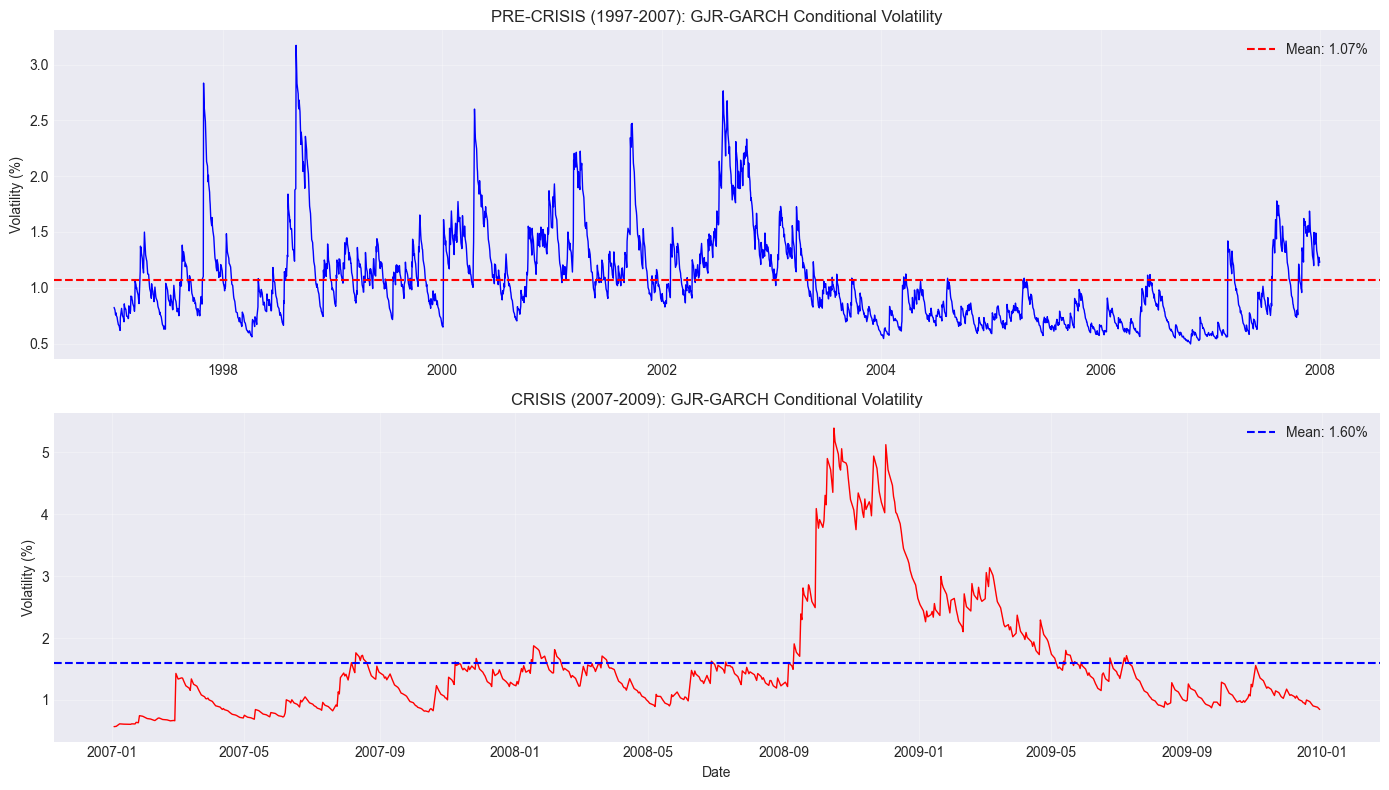

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Pre-Crisis Conditional Volatility
cond_vol_pre = results_pre.conditional_volatility
axes[0].plot(cond_vol_pre.index, cond_vol_pre, color='blue', linewidth=1)
axes[0].axhline(y=cond_vol_pre.mean(), color='red', linestyle='--', 
                label=f'Mean: {cond_vol_pre.mean():.2f}%')
axes[0].set_title('PRE-CRISIS (1997-2007): GJR-GARCH Conditional Volatility')
axes[0].set_ylabel('Volatility (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Crisis Conditional Volatility
cond_vol_crisis = results_crisis.conditional_volatility
axes[1].plot(cond_vol_crisis.index, cond_vol_crisis, color='red', linewidth=1)
axes[1].axhline(y=cond_vol_crisis.mean(), color='blue', linestyle='--', 
                label=f'Mean: {cond_vol_crisis.mean():.2f}%')
axes[1].set_title('CRISIS (2007-2009): GJR-GARCH Conditional Volatility')
axes[1].set_ylabel('Volatility (%)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/garch_volatility_comparison.png', dpi=150)
plt.show()